## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué performance presentan.

## 1. Carga datos y representa la serie

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
passengers = pd.read_csv('data/AirPassengers.csv')
passengers.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [23]:
passengers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [24]:
passengers["date"] = passengers["date"].astype(str)
passengers.loc[passengers["date"] == "nan", "date"] = None
passengers["year"] = passengers["date"].str.slice(0, 4)
passengers["month"] = passengers["date"].str.slice(5, 7)
passengers["day"] = "01"   # día fijo
passengers[["year", "month", "day"]] = passengers[["year", "month", "day"]].apply(
    pd.to_numeric, errors="coerce"
)
passengers["date"] = pd.to_datetime(
    passengers[["year", "month", "day"]],
    errors="coerce"
)

In [25]:
passengers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[ns]
 1   value   144 non-null    int64         
 2   year    144 non-null    int64         
 3   month   144 non-null    int64         
 4   day     144 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 5.8 KB


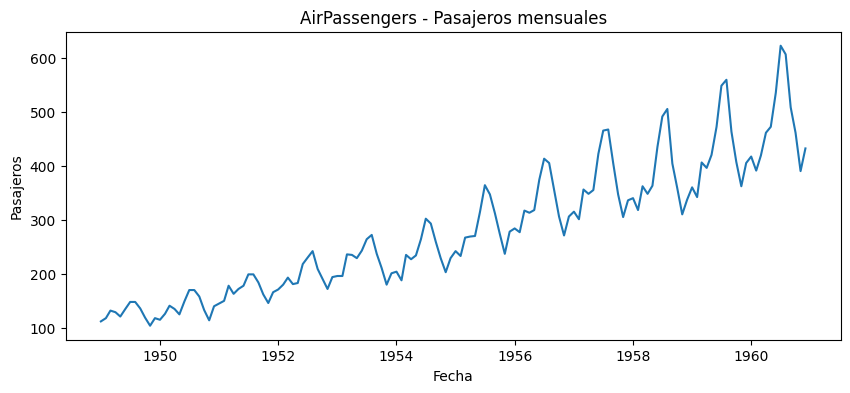

In [26]:
plt.figure(figsize=(10,4))
plt.plot(passengers["date"], passengers["value"])
plt.title("AirPassengers - Pasajeros mensuales")
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.show()

## 2. Crea en una gráfica la variable original con su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

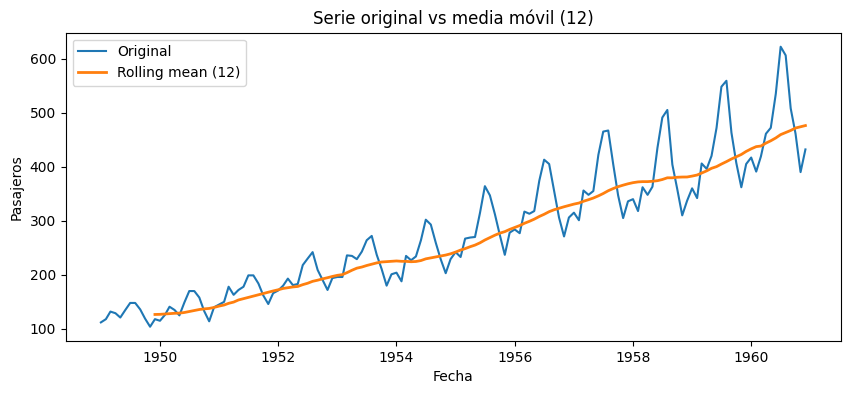

In [27]:
# Crear la media móvil con ventana 12
passengers["rolling_12"] = passengers["value"].rolling(window=12).mean()
plt.figure(figsize=(10,4))
plt.plot(passengers["date"], passengers["value"], label="Original")
plt.plot(passengers["date"], passengers["rolling_12"], label="Rolling mean (12)", linewidth=2)
plt.title("Serie original vs media móvil (12)")
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.legend()
plt.show()

## 3. Comprueba de manera estadística si la serie es o no stationary.

In [28]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(passengers["value"])

print("p-value:", result[1])

p-value: 0.991880243437641


## 4. Aplica una transformación logarítmica

In [29]:
import numpy as np

passengers["log_value"] = np.log(passengers["value"])

In [30]:
result_log = adfuller(passengers["log_value"])

print("p-value (log):", result_log[1])

p-value (log): 0.42236677477039125


## 5. Divide en train y test. Guarda 20 muestras para test.

In [31]:
X = passengers[['value']]
train = X[:-20]
test = X[-20:]

## 6. Crea tu primer modelo ARIMA

In [32]:
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error

model = auto_arima(train,
                    start_p=1,
                    start_q=1,
                    max_d=3,
                    max_p=5,
                    max_q=5,
                    trace=True,
                    stepwise=True)

print(model.aic())

predictions = model.predict(20)
print("mean_squared_error:", mean_squared_error(test, predictions))

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1164.464, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1180.340, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1174.338, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1171.576, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1179.124, Time=0.00 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1171.757, Time=0.03 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1163.079, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1170.015, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1172.799, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1156.122, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1170.365, T

## 7. Representa en una gráfica los datos de test y tus predicciones.

In [33]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt

# Entrenamos modelo sobre train
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# Forecast
forecast_log = model_fit.forecast(steps=len(test))

# Volvemos a escala original
forecast = np.exp(forecast_log)
test_real = np.exp(test)

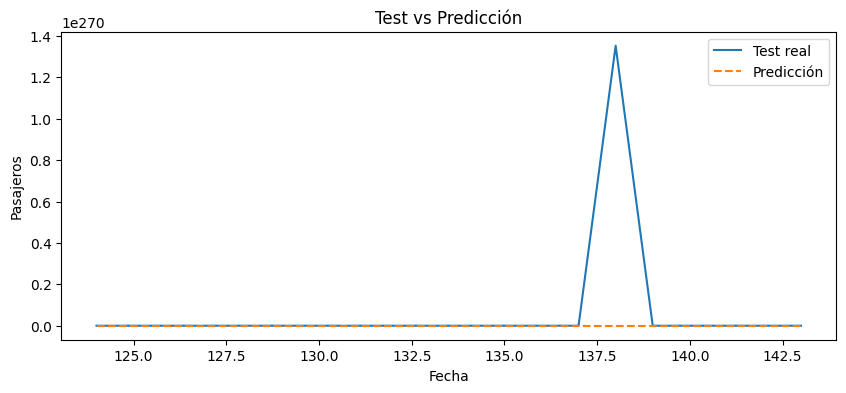

In [34]:
plt.figure(figsize=(10,4))
plt.plot(test_real.index, test_real, label="Test real")
plt.plot(test_real.index, forecast, label="Predicción", linestyle="--")
plt.title("Test vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.legend()
plt.show()

## 8. Prueba otros modelos, a ver qué performance presentan.

In [35]:
import pandas as pd

def create_lags(series, n_lags=12):
    df = pd.DataFrame(series)
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df.iloc[:, 0].shift(i)
    return df.dropna()

# Usamos la serie log
lagged = create_lags(passengers["log_value"], n_lags=12)

X = lagged.drop(columns="log_value")
y = lagged["log_value"]

In [36]:
X_train = X.iloc[:-20]
X_test = X.iloc[-20:]
y_train = y.iloc[:-20]
y_test = y.iloc[-20:]

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(
    np.exp(y_test),
    np.exp(pred_rf)
)

print("Random Forest MAE:", mae_rf)

Random Forest MAE: 37.864807273839766
